<div style="border-radius: 15px; padding: 25px; background-color: #1a1a2e; background-image: radial-gradient(circle at 15% 20%, #4a00e022, transparent 40%), radial-gradient(circle at 85% 70%, #8e2de222, transparent 40%); text-align: center; border: 1px solid #4a00e088;">
    <h1 style="color: #f0f0f0; font-weight: bold; font-size: 34px; text-shadow: 0 0 10px #8e2de2, 0 0 20px #4a00e0;">🧠✨ Binary Classification with a Bank Dataset </h1>
</div>

<div style="border-radius: 6px; padding: 15px 25px; background-color: #1a1a2e; text-align: left; border-left: 3px solid #6c5ce7;">
    <h1 style="color: #f0f0f0; font-family: 'SF Mono', 'Courier New', monospace; font-weight: normal; font-size: 24px; margin: 0;">✅ 1. Feature Understanding + Importance</h1>
    <p style="color: #ccc;">📌 <strong>Goal:</strong> Know which features matter most and why.</p>
    <ul style="color: #aaa;">
        <li><code>RandomForest.feature_importances_</code></li>
        <li><strong>SHAP</strong> values (very popular in Kaggle)</li>
    </ul>
    <p style="color: #7bed9f;">🧠 <strong>Why?</strong> Better features > better models. You can't build a great model on bad data.</p>
</div>

<div style="border-radius: 6px; padding: 15px 25px; background-color: #1a1a2e; text-align: left; border-left: 3px solid #6c5ce7; margin-top: 15px;">
    <h1 style="color: #f0f0f0; font-family: 'SF Mono', 'Courier New', monospace; font-weight: normal; font-size: 24px; margin: 0;">✅ 2. Target Leakage Detection</h1>
    <p style="color: #ccc;">📌 <strong>Goal:</strong> Make sure no feature gives away the answer too easily.</p>
    <ul style="color: #aaa;">
        <li>Adversarial validation</li>
        <li>Correlation with target</li>
        <li>Single-feature AUC test</li>
    </ul>
    <p style="color: #7bed9f;">🧠 <strong>Why?</strong> Leaky data gives high scores only in training. It fails in real life.</p>
</div>

<div style="border-radius: 6px; padding: 15px 25px; background-color: #1a1a2e; text-align: left; border-left: 3px solid #6c5ce7; margin-top: 15px;">
    <h1 style="color: #f0f0f0; font-family: 'SF Mono', 'Courier New', monospace; font-weight: normal; font-size: 24px; margin: 0;">✅ 3. Feature Engineering</h1>
    <p style="color: #ccc;">📌 <strong>Goal:</strong> Create new features from raw ones.</p>
    <ul style="color: #aaa;">
        <li>Ratios, sums, or interaction terms (e.g., <code>feature_1 * feature_2</code>)</li>
        <li>Grouping by category (e.g., mean encoding)</li>
        <li>Binning (convert continuous features to ranges)</li>
    </ul>
    <p style="color: #7bed9f;">🧠 <strong>Why?</strong> The biggest winners on Kaggle often don’t change models—they change features.</p>
</div>

<div style="border-radius: 6px; padding: 15px 25px; background-color: #1a1a2e; text-align: left; border-left: 3px solid #6c5ce7; margin-top: 15px;">
    <h1 style="color: #f0f0f0; font-family: 'SF Mono', 'Courier New', monospace; font-weight: normal; font-size: 24px; margin: 0;">✅ 4. Model Selection + Ensembling</h1>
    <p style="color: #ccc;">📌 <strong>Goal:</strong> Try multiple models and combine them.</p>
    <ul style="color: #aaa;">
        <li>XGBoost / LightGBM (best for tabular data)</li>
        <li>Stacking / Blending / Voting Ensembles</li>
        <li>Cross-validation (especially Stratified K-Fold)</li>
    </ul>
    <p style="color: #7bed9f;">🧠 <strong>Why?</strong> No one model wins every time. Ensembles give stability and higher accuracy.</p>
</div>

<div style="border-radius: 6px; padding: 15px 25px; background-color: #1a1a2e; text-align: left; border-left: 3px solid #6c5ce7; margin-top: 15px;">
    <h1 style="color: #f0f0f0; font-family: 'SF Mono', 'Courier New', monospace; font-weight: normal; font-size: 24px; margin: 0;">✅ 5. Hyperparameter Optimization</h1>
    <p style="color: #ccc;">📌 <strong>Goal:</strong> Find the best settings for your model.</p>
    <ul style="color: #aaa;">
        <li>GridSearchCV / RandomizedSearchCV</li>
        <li><strong>Optuna</strong> (modern, fast hyperparameter tuning)</li>
    </ul>
    <p style="color: #7bed9f;">🧠 <strong>Why?</strong> Even a good model can perform poorly with bad parameters.</p>
</div>


<div style="border-radius: 6px; padding: 15px 25px; background-color: #1a1a2e; text-align: left; border-left: 3px solid #6c5ce7;">
    <h1 style="color: #f0f0f0; font-family: 'SF Mono', 'Courier New', monospace; font-weight: normal; font-size: 24px; margin: 0;">🧠✨ Importing the Libraries </h1>
</div>

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
from scipy import stats
import seaborn as sns
import plotly.express as px
import plotly.io as pio

✅ Data loaded successfully!
Training data shape: (750000, 17)
Test data shape: (250000, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1


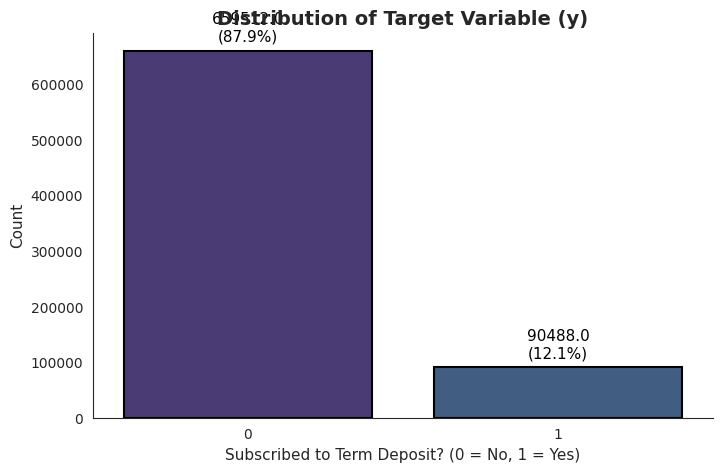

--- Numerical Features Summary ---


,count,mean,std,min,25%,50%,75%,max
age,750000.000000,40.926395,10.098829,18.000000,33.000000,39.000000,48.000000,95.000000
balance,750000.000000,1204.067397,2836.096759,-8019.000000,0.000000,634.000000,1390.000000,99717.000000
day,750000.000000,16.117209,8.250832,1.000000,9.000000,17.000000,21.000000,31.000000
duration,750000.000000,256.229144,272.555662,1.000000,91.000000,133.000000,361.000000,4918.000000
campaign,750000.000000,2.577008,2.718514,1.000000,1.000000,2.000000,3.000000,63.000000
pdays,750000.000000,22.412733,77.319998,-1.000000,-1.000000,-1.000000,-1.000000,871.000000
previous,750000.000000,0.298545,1.335926,0.000000,0.000000,0.000000,0.000000,200.000000
y,750000.000000,0.120651,0.325721,0.000000,0.000000,0.000000,0.000000,1.000000



--- Categorical Features Summary ---


,count,unique,top,freq
job,750000,12,management,175541
marital,750000,3,married,480759
education,750000,4,secondary,401683
default,750000,2,no,737151
housing,750000,2,yes,411288
loan,750000,2,no,645023
contact,750000,3,cellular,486655
month,750000,12,may,228411
poutcome,750000,4,unknown,672450



--- Unique Values & Potential Issues ---


,Column,Is_Numeric,Unique_Values
5,balance,True,8217
11,duration,True,1760
13,pdays,True,596
0,age,True,78
12,campaign,True,52
14,previous,True,50
9,day,True,31
1,job,False,12
10,month,False,12
15,poutcome,False,4


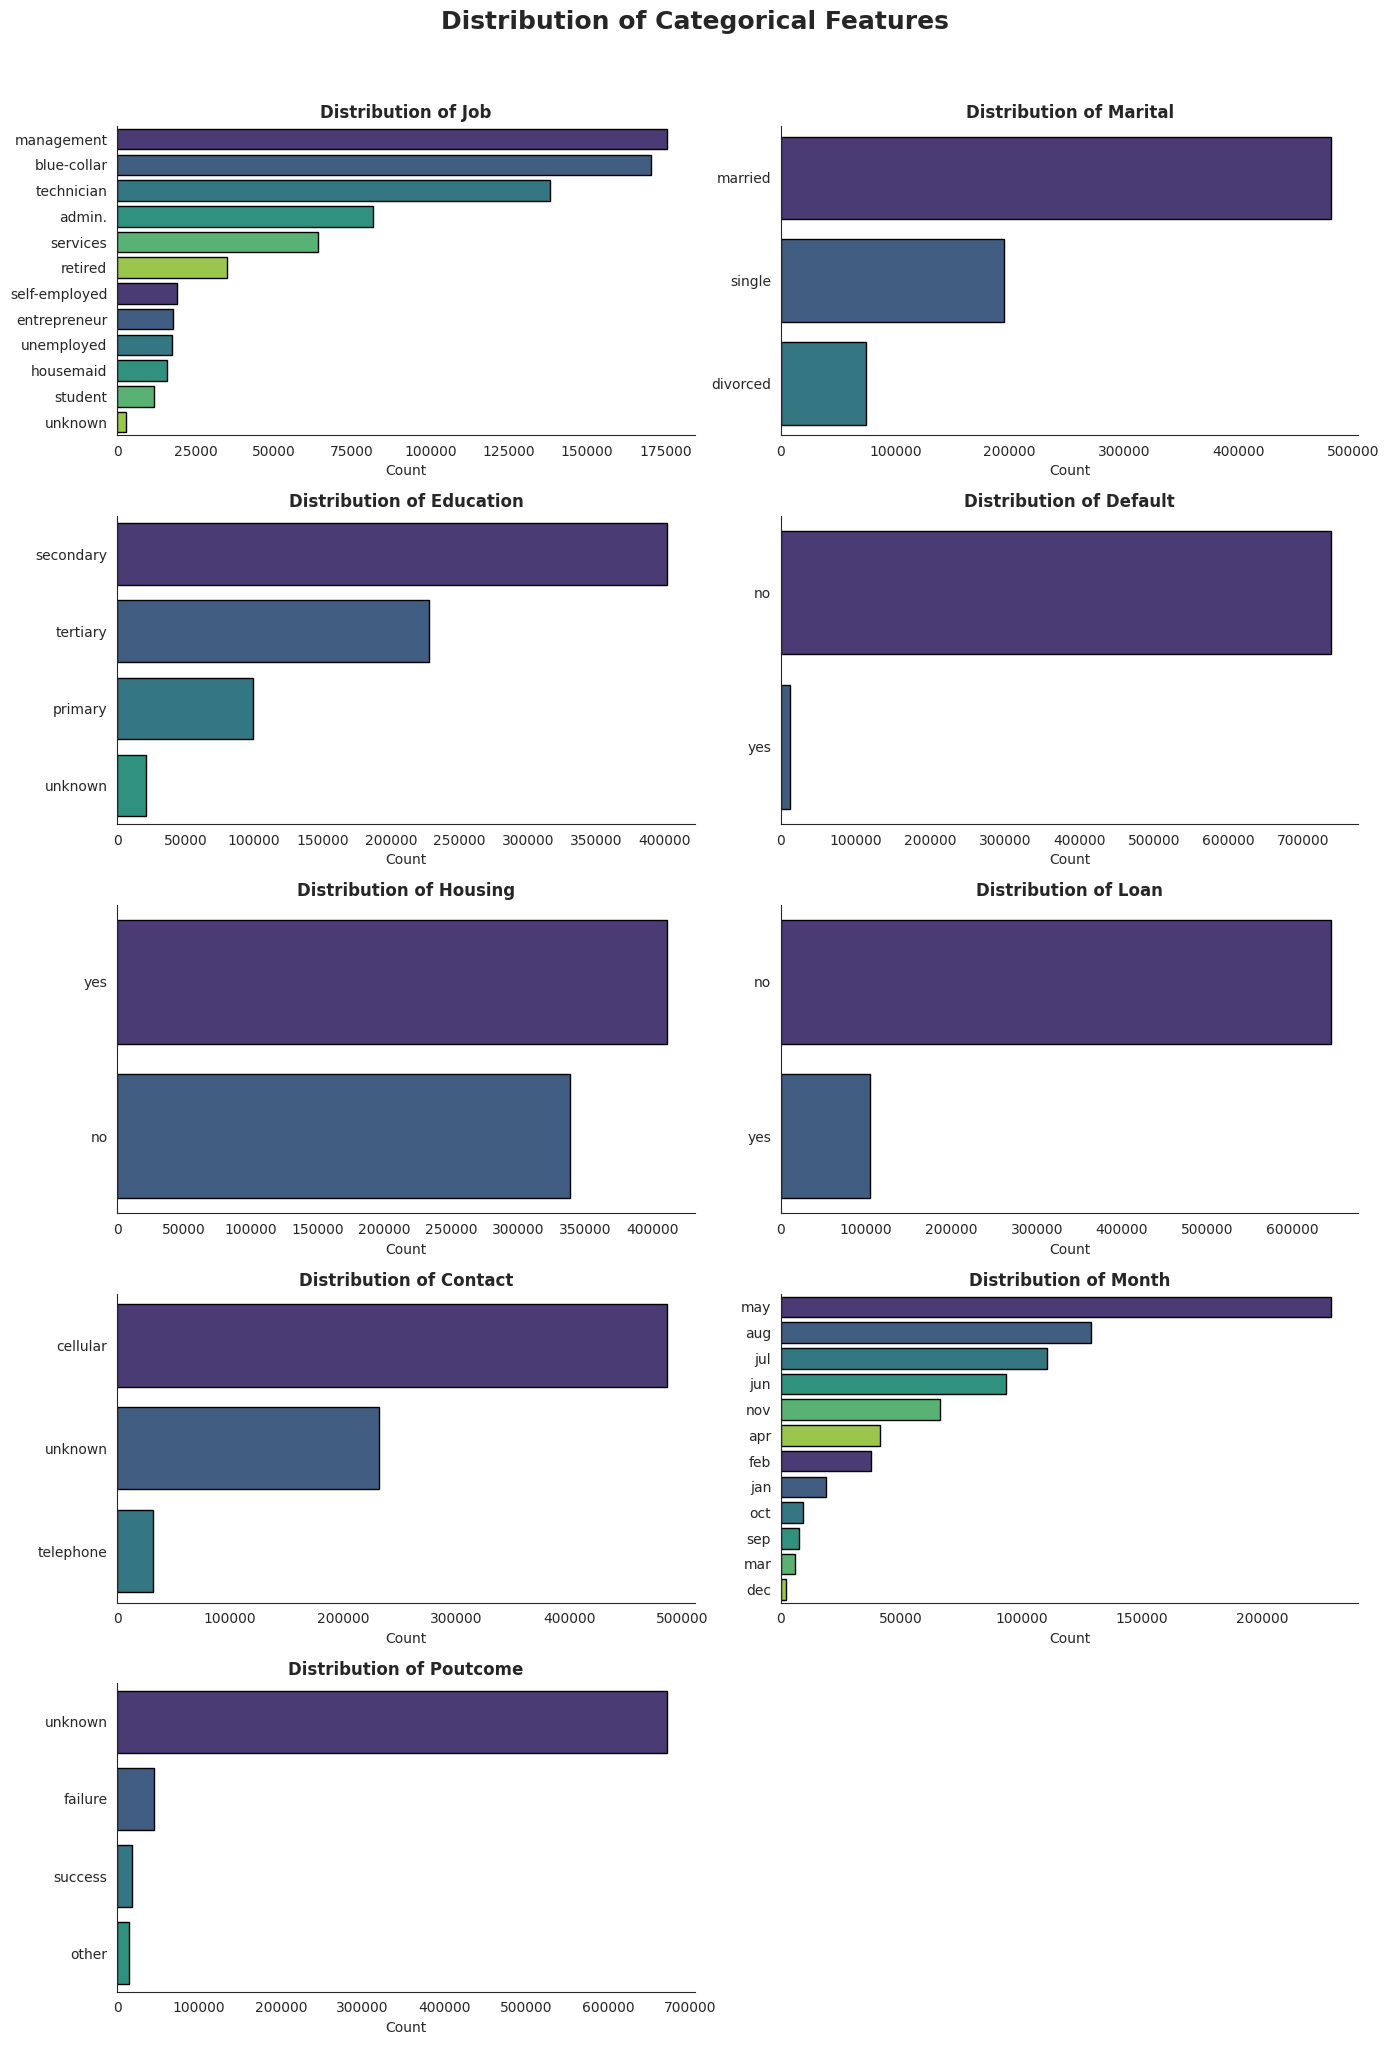

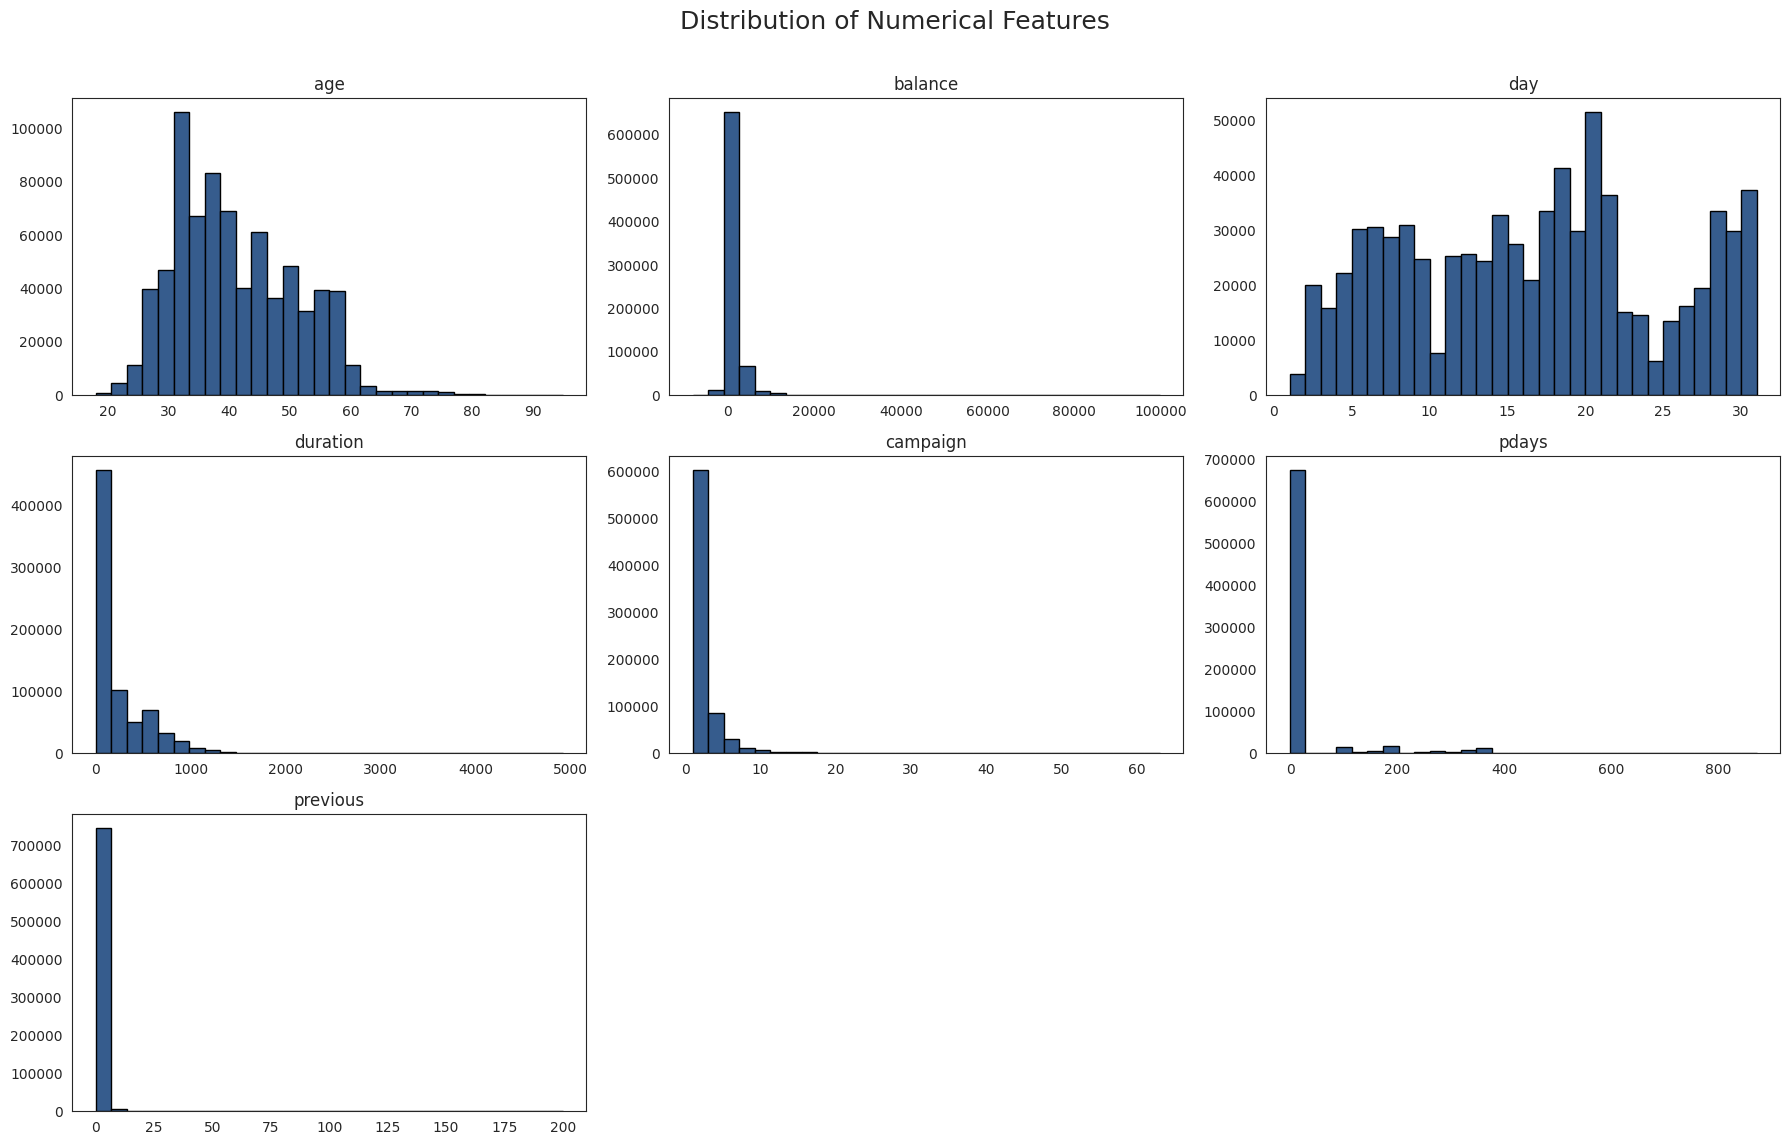

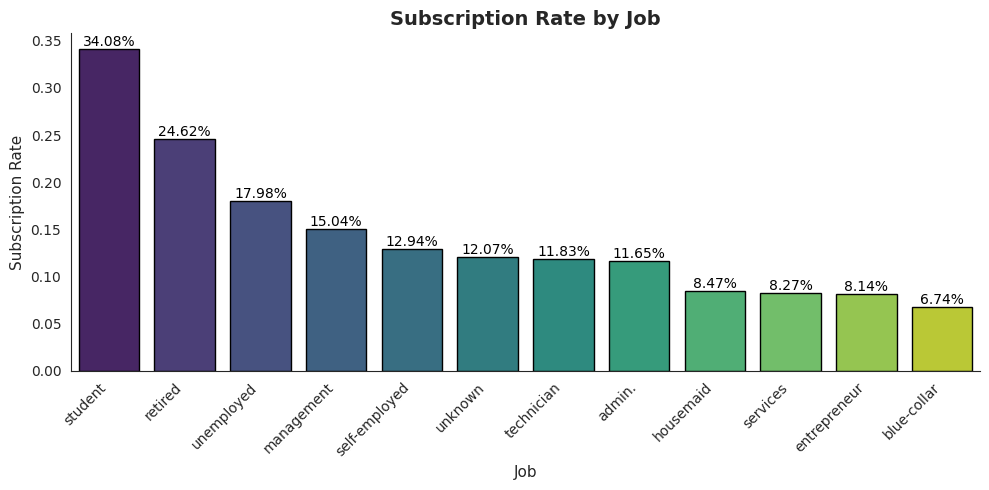

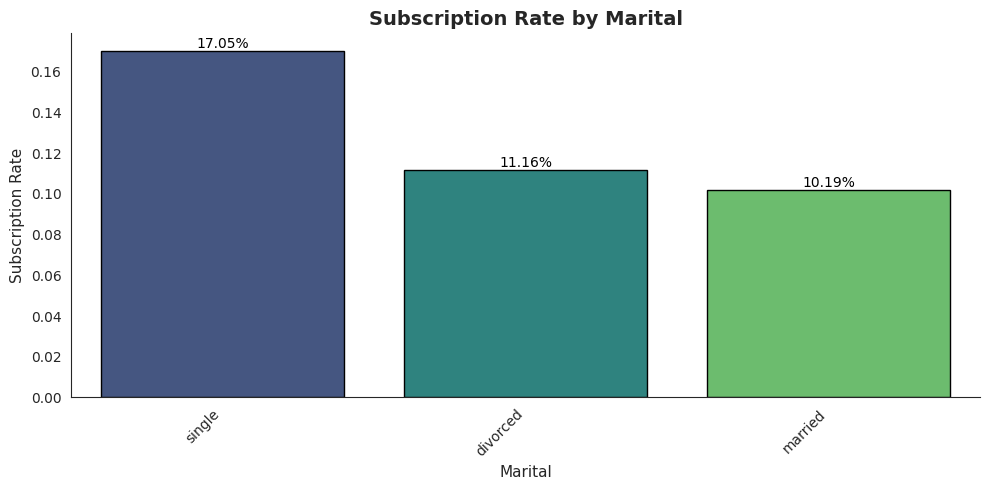

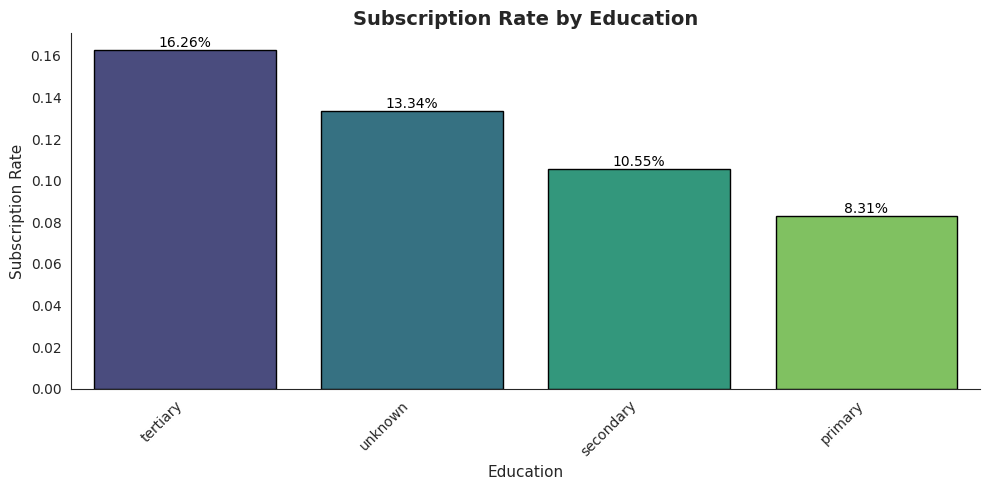

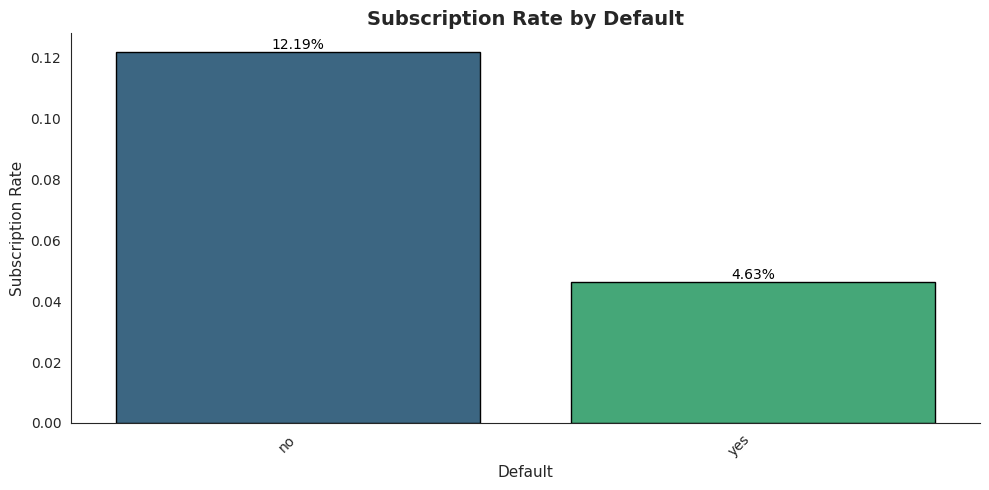

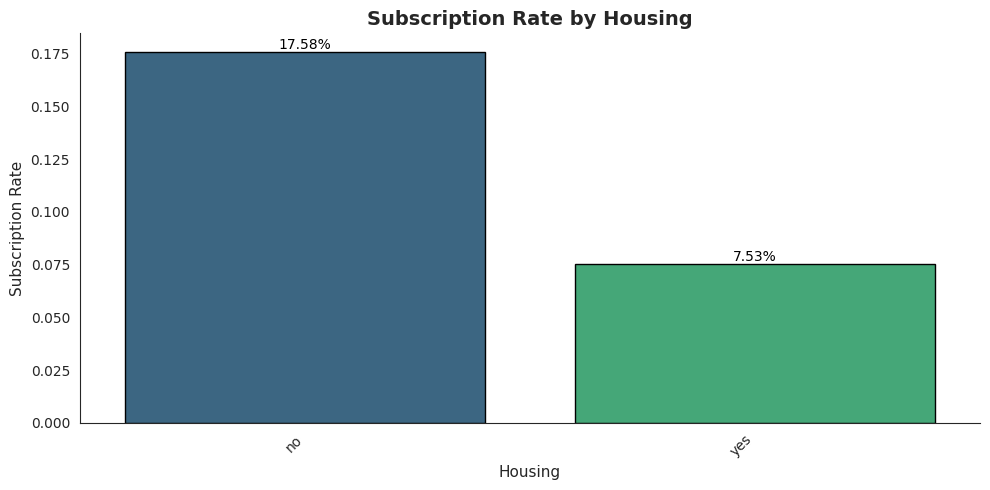

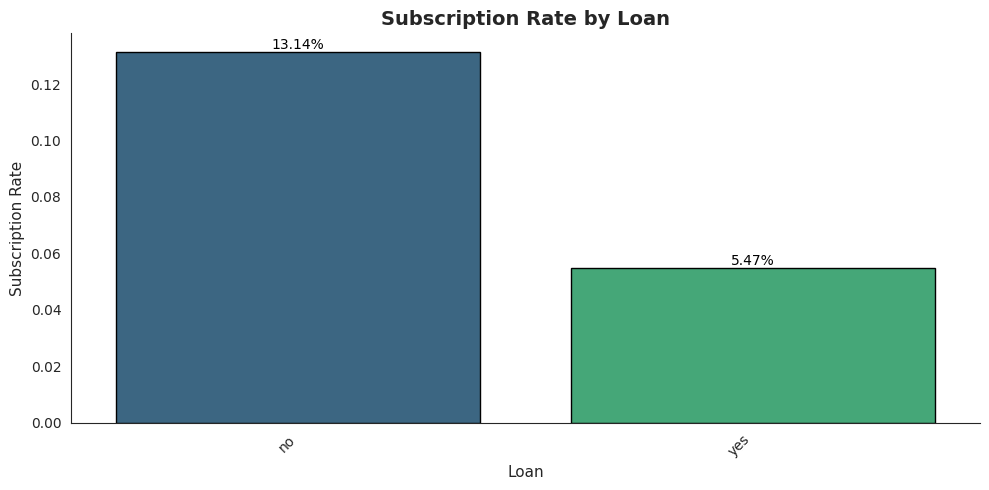

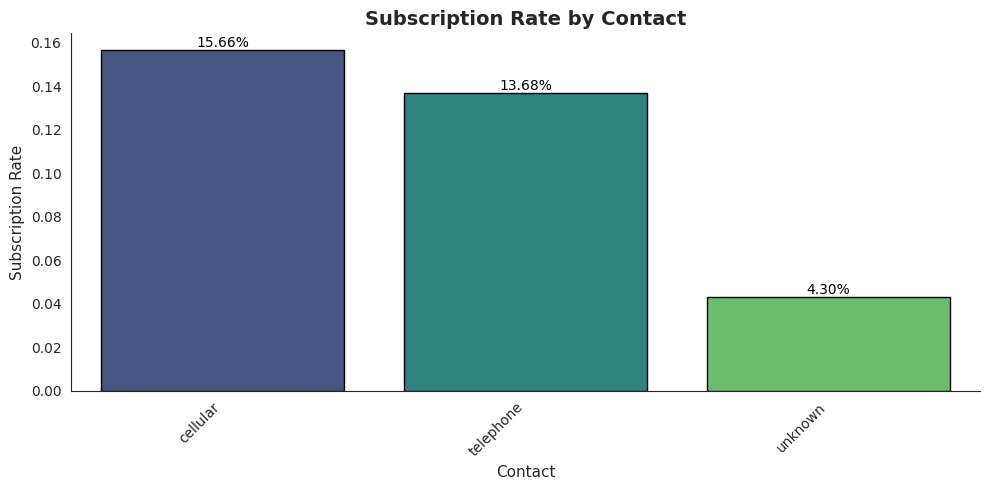

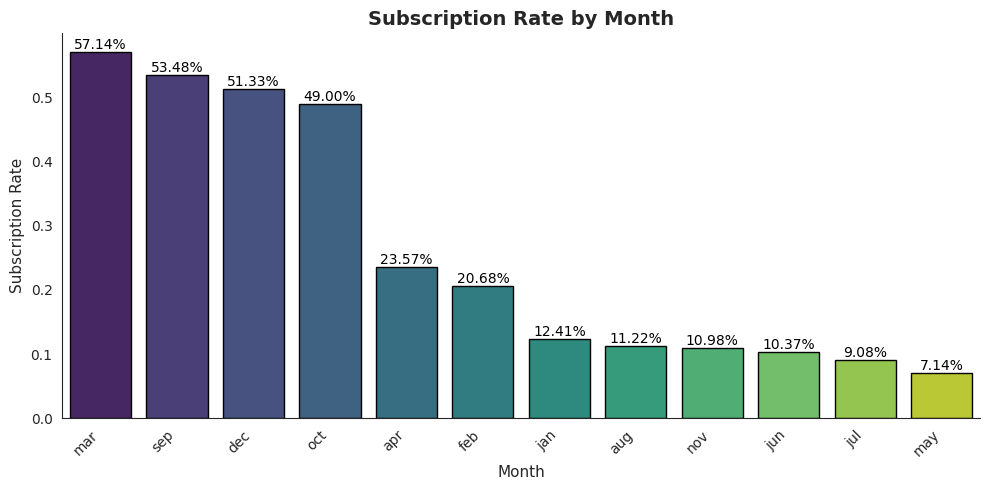

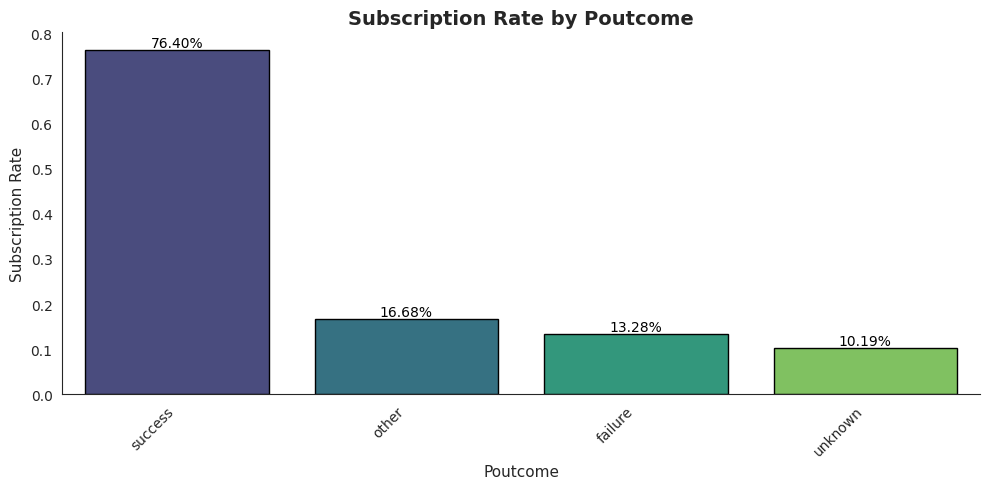

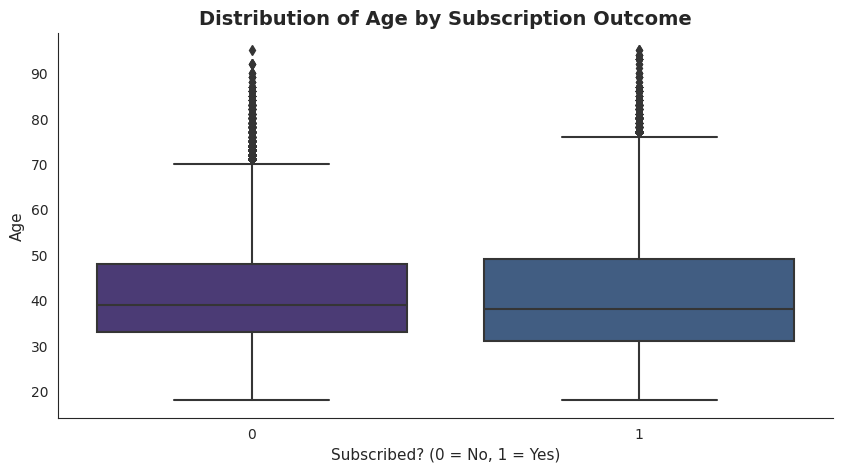

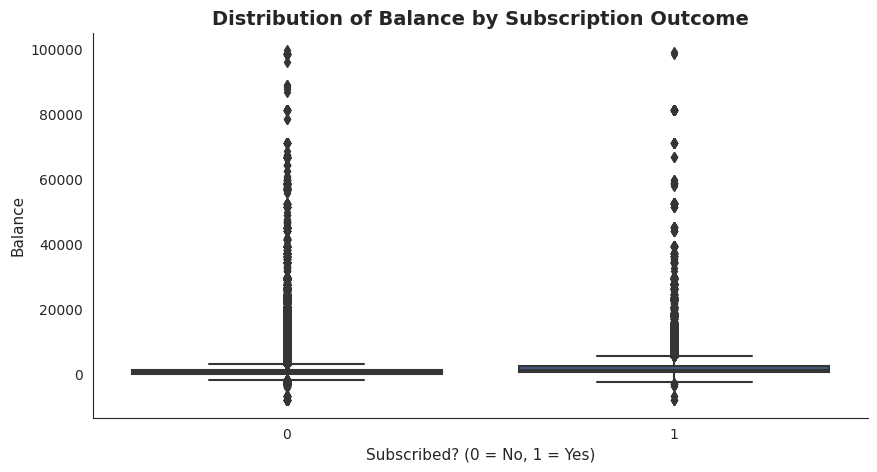

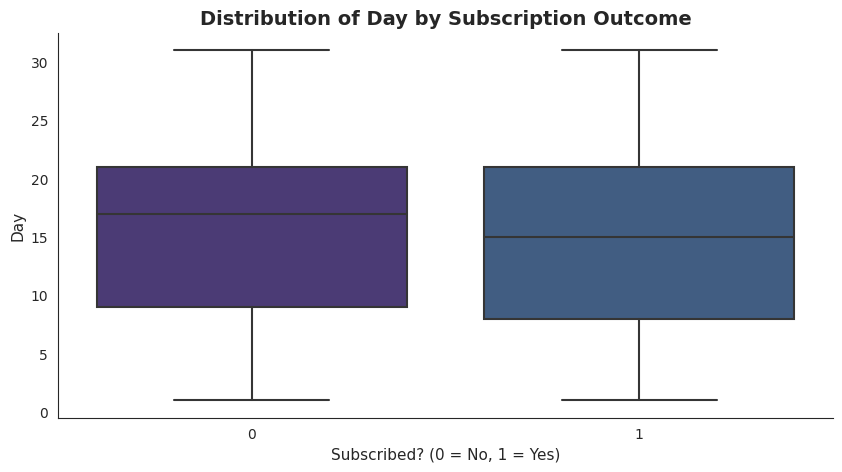

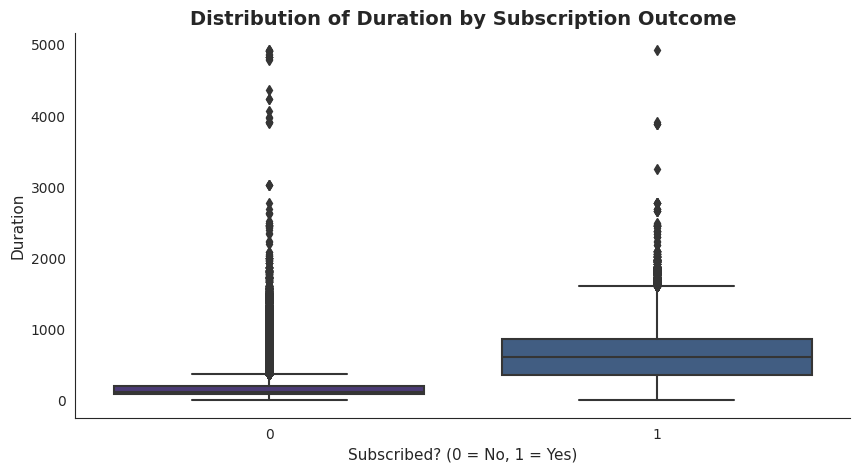

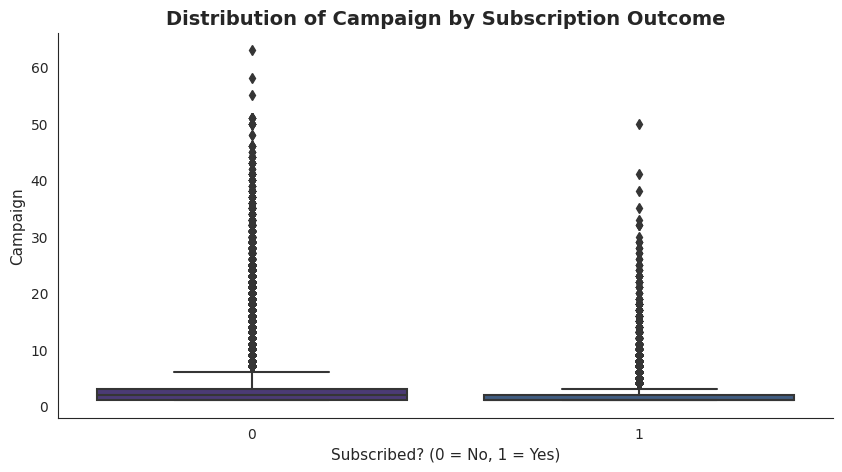

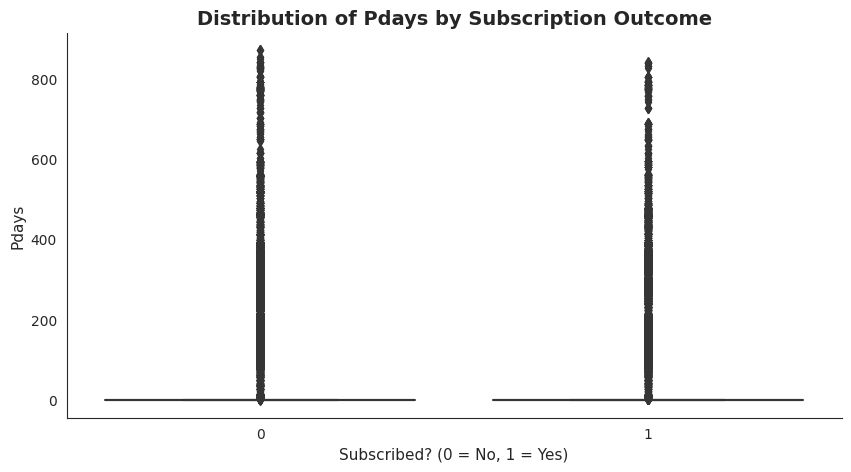

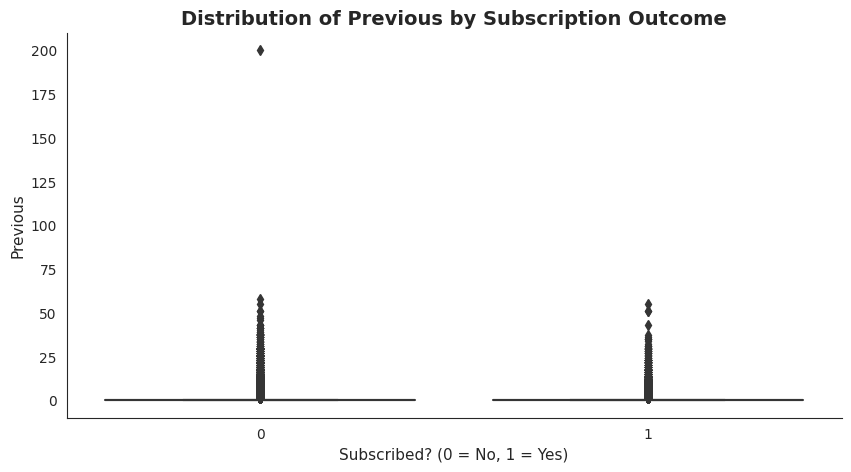

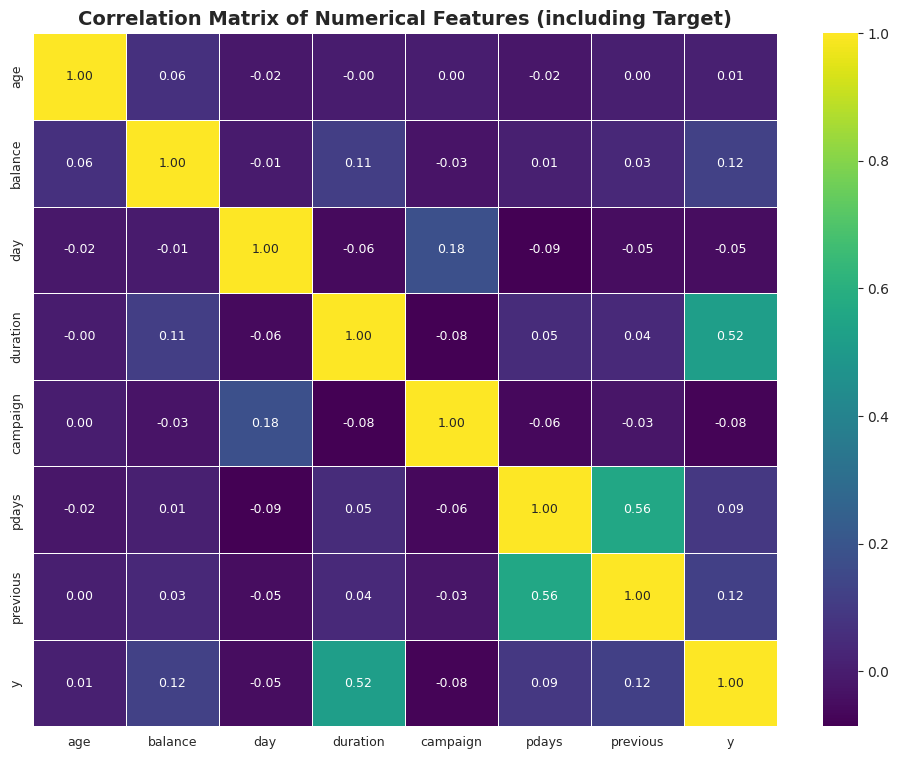

In [2]:
# --- Style & Settings ---
# Set a clean, simple style with a white background
sns.set_style("white") 
# Set the color palette
palette = sns.color_palette("viridis")
# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set the default renderer for Plotly to ensure plots are visible
pio.renderers.default = 'kaggle'

# --- Custom Heading Function ---
from IPython.display import display, HTML

def print_heading(title):
    """Prints a styled heading for notebook sections."""
    html_code = f"""
    <div style="border-radius: 6px; padding: 15px 25px; background-color: #1a1a2e; text-align: left; border-left: 3px solid #6c5ce7; margin-top: 20px; margin-bottom: 10px;">
        <h1 style="color: #f0f0f0; font-family: 'SF Mono', 'Courier New', monospace; font-weight: normal; font-size: 24px; margin: 0;">{title}</h1>
    </div>
    """
    display(HTML(html_code))

# --- 1. Load Data ---
print_heading("🧠✨ 1. Loading the Datasets")

# Load the datasets from the provided paths
try:
    tr = pd.read_csv("/kaggle/input/playground-series-s5e8/train.csv")
    ts = pd.read_csv("/kaggle/input/playground-series-s5e8/test.csv")
    sub = pd.read_csv("/kaggle/input/playground-series-s5e8/sample_submission.csv")
    
    # Drop the 'id' column from the training data as it's not a feature
    tr = tr.drop('id', axis=1)

    print("✅ Data loaded successfully!")
    print(f"Training data shape: {tr.shape}")
    print(f"Test data shape: {ts.shape}")
    
except FileNotFoundError:
    print("❌ Error: Make sure the file paths are correct.")
    # As a fallback for local execution, create dummy dataframes
    tr = pd.DataFrame() 
    ts = pd.DataFrame()

if not tr.empty:
    display(tr.head())

    # --- 2. Target Variable Analysis ---
    print_heading("🎯📈 2. Target Variable Analysis")
    plt.figure(figsize=(8, 5)) 
    ax = sns.countplot(x='y', data=tr, palette=palette, order=tr['y'].value_counts().index, 
                       edgecolor='black', linewidth=1.5)
    plt.title('Distribution of Target Variable (y)', fontsize=14, fontweight='bold')
    plt.xlabel('Subscribed to Term Deposit? (0 = No, 1 = Yes)', fontsize=11)
    plt.ylabel('Count', fontsize=11)
    total = len(tr)
    for p in ax.patches:
        count = p.get_height()
        percentage = f'{100 * count / total:.1f}%'
        label = f'{count}\n({percentage})'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(label, (x, y), ha='center', va='bottom', fontsize=11, color='black',
                    xytext=(0, 5), textcoords='offset points')
    sns.despine()
    plt.show()

    # --- 3. Deep Statistical Analysis ---
    print_heading("🕵️‍♂️📊 3. Deep Statistical Analysis")
    
    print("--- Numerical Features Summary ---")
    display(tr.describe().T.style.bar(subset=['mean'], color='#21908d')
                                 .background_gradient(subset=['std'], cmap='viridis')
                                 .background_gradient(subset=['50%'], cmap='viridis'))
    
    print("\n--- Categorical Features Summary ---")
    display(tr.describe(include=['object']).T)
    
    print("\n--- Unique Values & Potential Issues ---")
    summary = []
    for col in tr.columns:
        unique_count = tr[col].nunique()
        is_numeric = pd.api.types.is_numeric_dtype(tr[col])
        summary.append({'Column': col, 'Is_Numeric': is_numeric, 'Unique_Values': unique_count})
    
    summary_df = pd.DataFrame(summary)
    display(summary_df.sort_values(by='Unique_Values', ascending=False).style.background_gradient(cmap='viridis', subset=['Unique_Values']))
    
    display(HTML("""
    <div style='margin-top: 15px; padding: 10px; background-color: #f0f8ff; border-radius: 5px; color: #1c1c1c;'>
    <b>Interpretation of Statistical Dive:</b>
    <ul>
        <li><b>Numerical Summary:</b> The styled table helps us quickly spot key stats. A large difference between 'mean' and '50%' (median) indicates skewness (e.g., in 'balance').</li>
        <li><b>Categorical Summary:</b> This shows the number of unique categories ('unique'), the most frequent one ('top'), and its count ('freq').</li>
        <li><b>Unique Values Table:</b> Crucial for identifying feature types. High cardinality in 'duration' and 'balance' confirms they are continuous. Low counts confirm other features are categorical.</li>
    </ul>
    </div>
    """))

    # --- 4. Univariate Analysis (Distribution of Single Features) ---
    print_heading("📊 4. Univariate Feature Analysis")
    
    categorical_cols = tr.select_dtypes(include=['object']).columns.tolist()
    numerical_cols = tr.select_dtypes(include=np.number).columns.tolist()
    numerical_cols.remove('y')
    
    # --- Categorical Feature Distribution (Using Subplots) ---
    n_cols = 2
    n_rows = (len(categorical_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(categorical_cols):
        ax = axes[i]
        sns.countplot(y=col, data=tr, order=tr[col].value_counts().index, palette=palette,
                      edgecolor='black', linewidth=1, ax=ax)
        ax.set_title(f'Distribution of {col.capitalize()}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Count', fontsize=10)
        ax.set_ylabel('')
        sns.despine(ax=ax)

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle('Distribution of Categorical Features', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # --- Numerical Feature Distribution ---
    tr[numerical_cols].hist(bins=30, figsize=(18, 12), color=palette[1], ec='black', grid=False)
    plt.suptitle('Distribution of Numerical Features', size=18, y=0.95)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

    # --- 5. Bivariate Analysis (Feature vs. Target) ---
    print_heading("📈🔗 5. Bivariate Analysis: Finding Predictive Patterns")

    # --- Categorical Features vs. Target ---
    display(HTML("<h3 style='color: #1a1a2e;'>Categorical Features vs. Subscription Rate</h3>"))
    for col in categorical_cols:
        rate_df = tr.groupby(col)['y'].mean().sort_values(ascending=False).to_frame()
        plt.figure(figsize=(10, 5))
        ax = sns.barplot(x=rate_df.index, y=rate_df['y'], palette="viridis", edgecolor='black')
        plt.title(f'Subscription Rate by {col.capitalize()}', fontsize=14, fontweight='bold')
        plt.xlabel(col.capitalize(), fontsize=11)
        plt.ylabel('Subscription Rate', fontsize=11)
        plt.xticks(rotation=45, ha='right')
        for p in ax.patches:
            ax.annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                        textcoords='offset points')
        sns.despine()
        plt.tight_layout()
        plt.show()

    # --- Numerical Features vs. Target ---
    display(HTML("<h3 style='color: #1a1a2e; margin-top: 20px;'>Numerical Features vs. Subscription Outcome</h3>"))
    for col in numerical_cols:
        plt.figure(figsize=(10, 5))
        sns.boxplot(x='y', y=col, data=tr, palette=palette)
        plt.title(f'Distribution of {col.capitalize()} by Subscription Outcome', fontsize=14, fontweight='bold')
        plt.xlabel('Subscribed? (0 = No, 1 = Yes)', fontsize=11)
        plt.ylabel(col.capitalize(), fontsize=11)
        sns.despine()
        plt.show()

    # --- 6. Correlation Analysis ---
    print_heading("🔗 heatmap 6. Correlation Heatmap")
    corr_matrix = tr[numerical_cols + ['y']].corr() # Include target in correlation
    plt.figure(figsize=(12, 9))
    sns.heatmap(corr_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=.5, annot_kws={"size": 9})
    plt.title('Correlation Matrix of Numerical Features (including Target)', fontsize=14, fontweight='bold')
    plt.xticks(fontsize=9)
    plt.yticks(fontsize=9)
    plt.show()



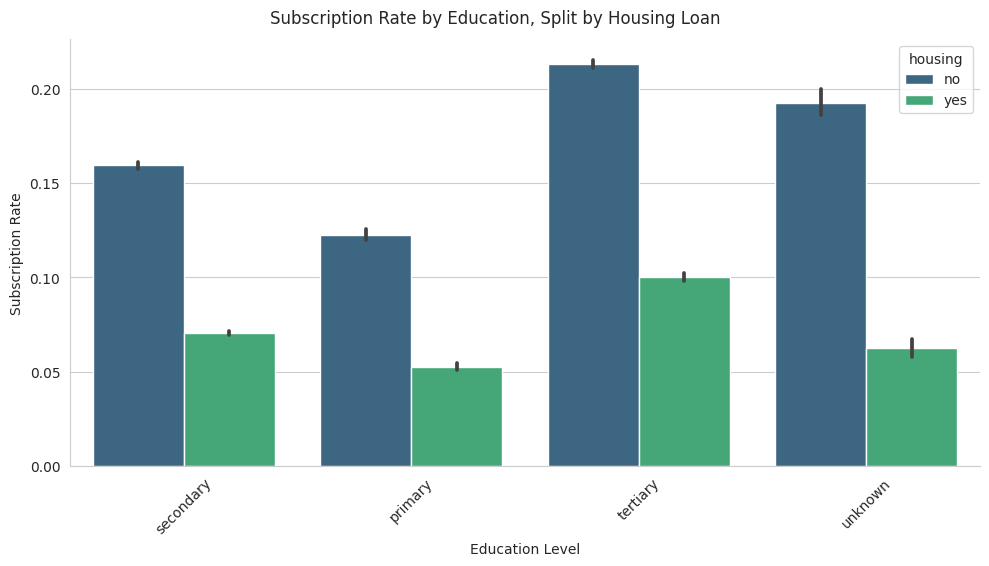

Chi-Squared Test for 'poutcome' vs 'y': P-value = 0.0


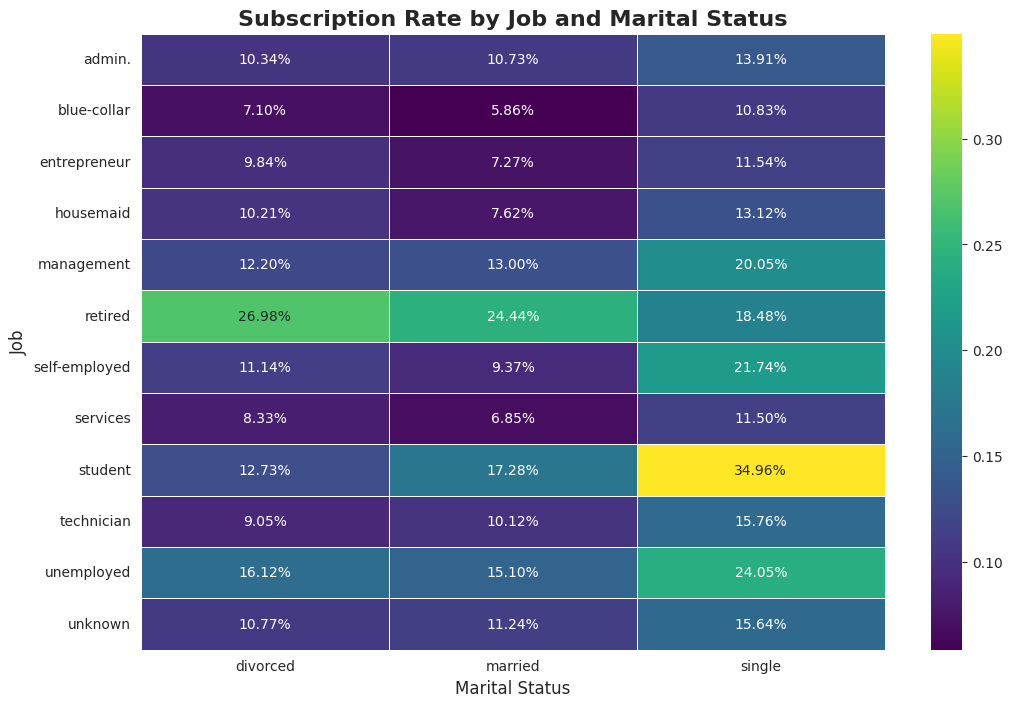

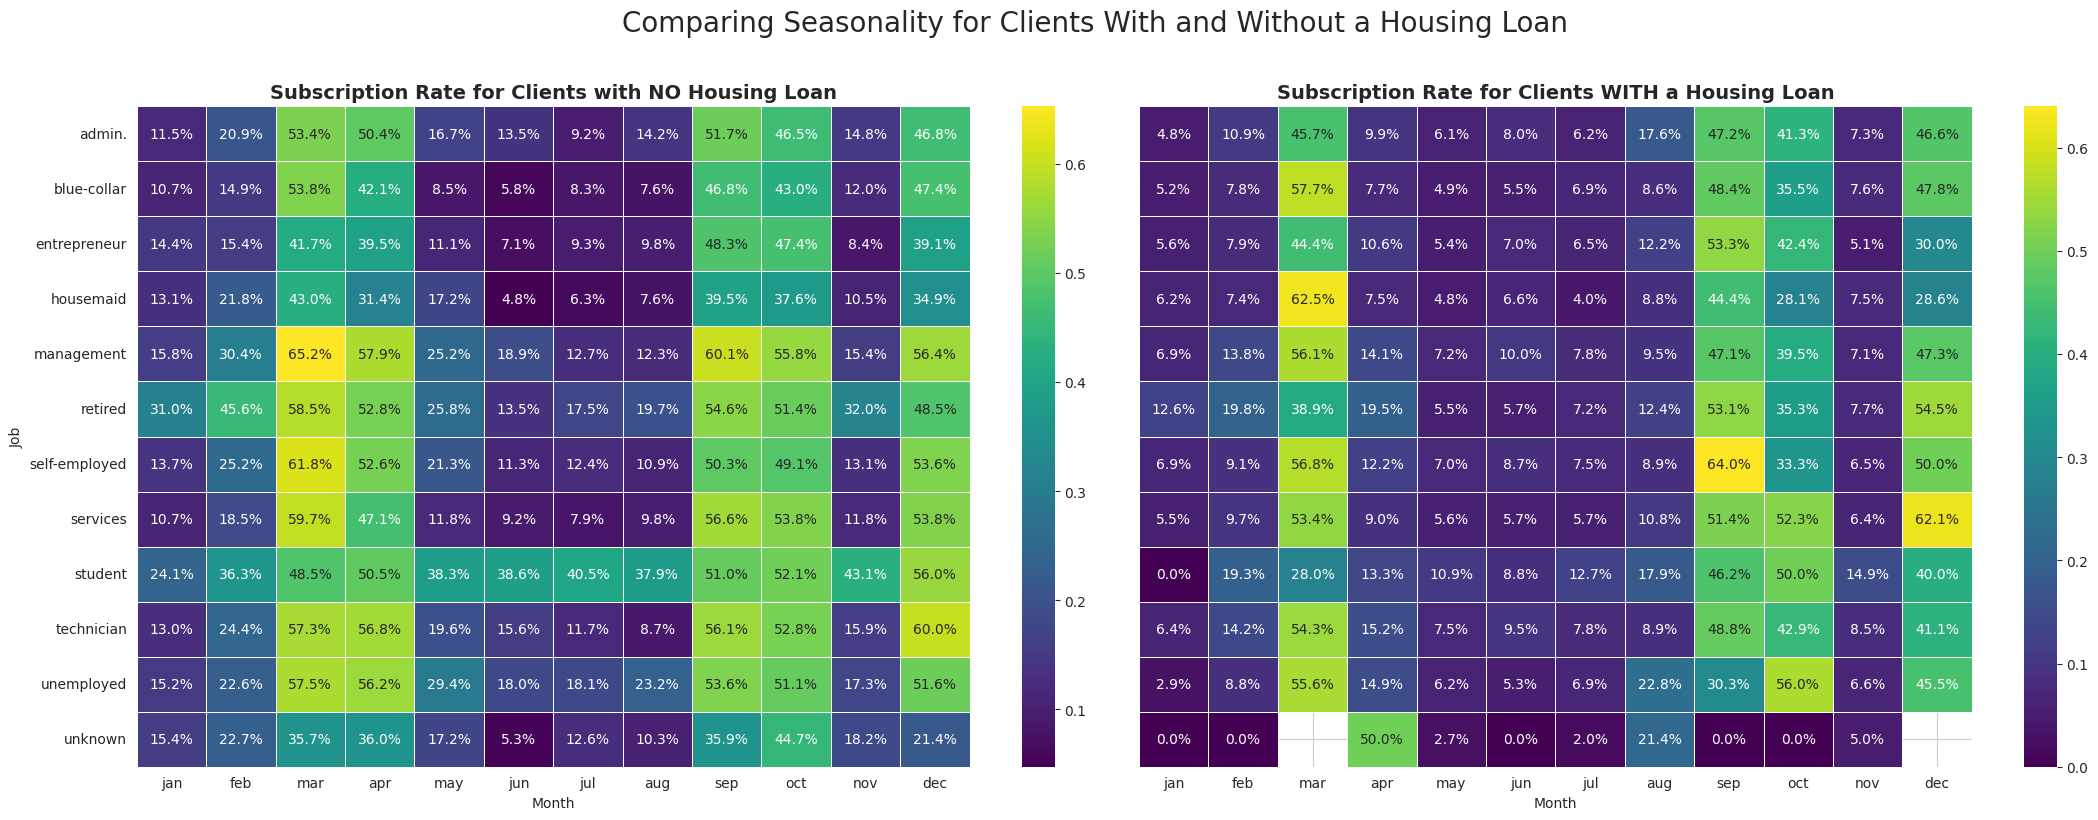

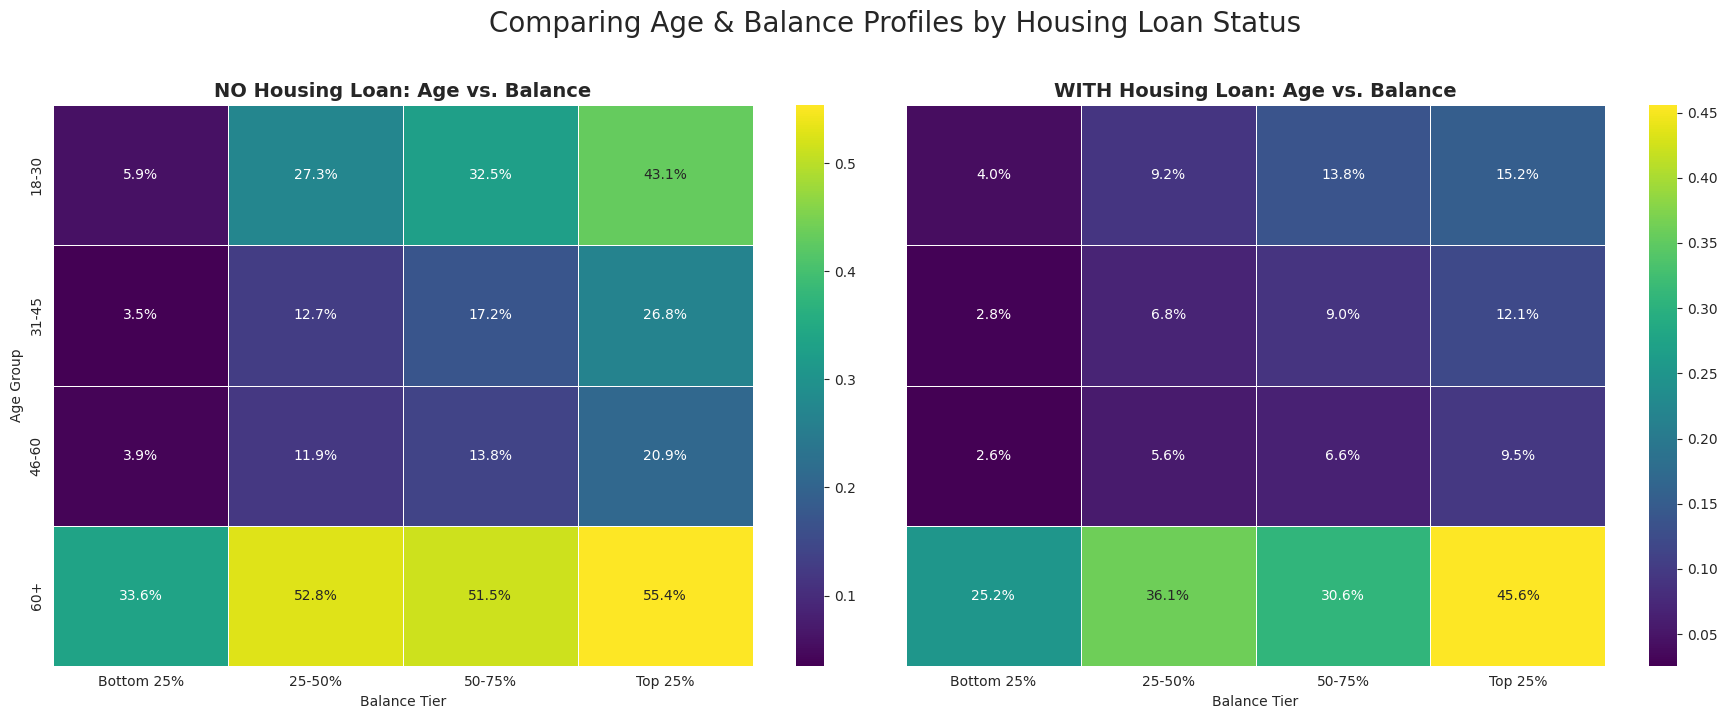

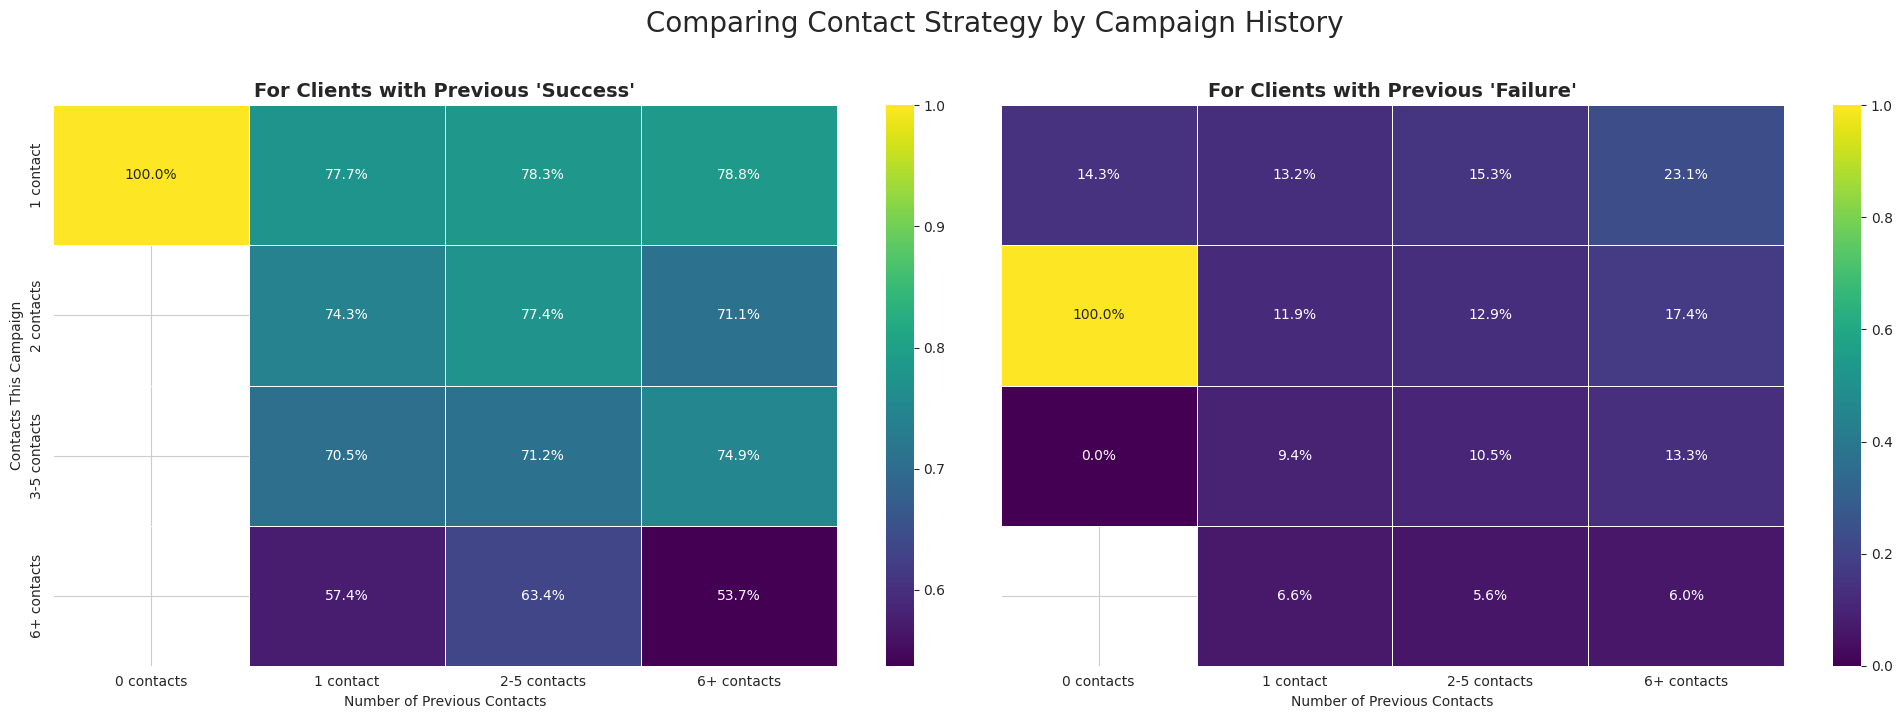

In [3]:

# --- Style & Settings ---
sns.set_style("whitegrid")
palette = sns.color_palette("viridis")
warnings.filterwarnings('ignore')

# --- Custom Heading Function ---
from IPython.display import display, HTML

def print_heading(title, level=1):
    """Prints a styled heading for notebook sections."""
    if level == 1:
        html_code = f"""
        <div style="border-radius: 6px; padding: 15px 25px; background-color: #1a1a2e; text-align: left; border-left: 3px solid #6c5ce7; margin-top: 20px; margin-bottom: 10px;">
            <h1 style="color: #f0f0f0; font-family: 'SF Mono', 'Courier New', monospace; font-weight: normal; font-size: 24px; margin: 0;">{title}</h1>
        </div>
        """
    else:
        html_code = f"<h{level+1} style='color: #1a1a2e; margin-top: 15px;'>{title}</h{level+1}>"
    display(HTML(html_code))

def print_interpretation(text):
    """Prints a styled interpretation box."""
    html_code = f"""
    <div style='margin-top: 10px; margin-bottom: 20px; padding: 15px; background-color: #f0f8ff; border-left: 5px solid #17a2b8; border-radius: 5px; color: #1c1c1c;'>
    <b>In Simple Words:</b><br>
    {text}
    </div>
    """
    display(HTML(html_code))

# --- Load Data ---
# Assuming 'tr' dataframe is loaded from the previous step
try:
    tr = pd.read_csv("/kaggle/input/playground-series-s5e8/train.csv")
    tr = tr.drop('id', axis=1)
except FileNotFoundError:
    print("Please load the training data first.")
    tr = pd.DataFrame()

if not tr.empty:
    # --- 1. Multivariate Analysis: Uncovering Interactions ---
    print_heading("🔎 1. Multivariate Analysis: How Features Interact")

    print_heading("Subscription Rate by Education, Faceted by Housing Loan Status", level=2)
    
    g = sns.catplot(data=tr, x='education', y='y', hue='housing',
                    kind='bar', palette='viridis', height=5, aspect=2,
                    legend_out=False)
    g.fig.suptitle('Subscription Rate by Education, Split by Housing Loan', y=1.03)
    plt.ylabel("Subscription Rate")
    plt.xlabel("Education Level")
    plt.xticks(rotation=45)
    plt.show()

    print_interpretation("""
    This chart shows the subscription rate for each education level, split by whether a person has a housing loan.
    <ul>
        <li><b>What we found:</b> People <b>without a housing loan</b> (the lighter bars) are more likely to subscribe, no matter their education level.</li>
        <li><b>What this means:</b> Not having a housing loan is a good sign. The combination of 'tertiary' education and 'no' housing loan is an especially strong signal for a 'yes' subscription. This tells us that creating a feature that combines these two could be very useful for our model.</li>
    </ul>
    """)

    # --- 2. Formal Statistical Tests: Adding Rigor ---
    print_heading("🔬 2. Formal Statistical Tests: Are the Differences Real?")

    print_heading("Chi-Squared Test (Categorical vs. Target)", level=2)
    contingency_table = pd.crosstab(tr['poutcome'], tr['y'])
    chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
    print(f"Chi-Squared Test for 'poutcome' vs 'y': P-value = {p}")
    
    print_interpretation(f"""
    The p-value is basically zero. A p-value this low tells us that the relationship between the previous campaign's outcome ('poutcome') and the current subscription result is <b>not random</b>.
    <br><b>Conclusion:</b> 'poutcome' is a genuinely predictive feature. Knowing if a person said 'yes' before helps us predict if they'll say 'yes' again.
    """)

    # --- 3. Pivot Table Analysis: A Deeper Look at Interactions ---
    print_heading("🔢 3. Pivot Table Analysis: Quantifying Interactions")

    print_heading("Subscription Rate by Job and Marital Status", level=2)
    
    pivot_df_job_marital = pd.pivot_table(tr, values='y', index='job', columns='marital', aggfunc=np.mean)
    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot_df_job_marital, annot=True, fmt='.2%', cmap='viridis', linewidths=.5)
    plt.title('Subscription Rate by Job and Marital Status', fontsize=16, fontweight='bold')
    plt.xlabel('Marital Status', fontsize=12)
    plt.ylabel('Job', fontsize=12)
    plt.show()

    best_group = pivot_df_job_marital.stack().idxmax()
    best_rate = pivot_df_job_marital.stack().max()
    summary_text = f"""
    This heatmap shows the percentage of people in each specific group (job + marital status) who subscribed.
    <ul>
        <li><b>Highest Success Rate:</b> The most successful group is <b>'{best_group[1]}' '{best_group[0]}s'</b>, with a subscription rate of <b>{best_rate:.2%}</b>.</li>
        <li><b>What this means:</b> This confirms that the combination of job and marital status is a better predictor than either one alone.</li>
    </ul>
    """
    print_interpretation(summary_text)

    # --- 4. Three-Way Interaction Analysis: The Deepest Dive ---
    print_heading("💎 4. Three-Way Interaction Analysis")
    
    # Ensure month order is chronological for better visualization
    month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
    tr['month'] = pd.Categorical(tr['month'], categories=month_order, ordered=True)

    print_heading("Interaction 1: Seasonality vs. Housing Loan", level=2)
    tr_housing_no = tr[tr['housing'] == 'no']
    tr_housing_yes = tr[tr['housing'] == 'yes']
    pivot_no_loan = pd.pivot_table(tr_housing_no, values='y', index='job', columns='month', aggfunc=np.mean)
    pivot_yes_loan = pd.pivot_table(tr_housing_yes, values='y', index='job', columns='month', aggfunc=np.mean)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8), sharey=True)
    sns.heatmap(pivot_no_loan, annot=True, fmt='.1%', cmap='viridis', linewidths=.5, ax=ax1)
    ax1.set_title('Subscription Rate for Clients with NO Housing Loan', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Month'); ax1.set_ylabel('Job')
    sns.heatmap(pivot_yes_loan, annot=True, fmt='.1%', cmap='viridis', linewidths=.5, ax=ax2)
    ax2.set_title('Subscription Rate for Clients WITH a Housing Loan', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Month'); ax2.set_ylabel('')
    plt.suptitle('Comparing Seasonality for Clients With and Without a Housing Loan', fontsize=20, y=1.02)
    plt.tight_layout(); plt.show()

    best_rate_no_loan = pivot_no_loan.stack().max()
    best_group_no_loan = pivot_no_loan.stack().idxmax()
    summary_text = f"""
    This analysis confirms that people without a housing loan are much more likely to subscribe, especially in the 'hot' months.
    <ul>
        <li><b>The Ultimate Combination:</b> The single best group to target is <b>'{best_group_no_loan[0]}s' with no housing loan in {best_group_no_loan[1].capitalize()}</b>. This group had an incredible subscription rate of <b>{best_rate_no_loan:.1%}</b>!</li>
        <li><b>What this means:</b> We have found a powerful three-way interaction. A feature that signals "Is a student OR retired AND has no housing loan AND was contacted in March/September/October/December" would likely be one of the strongest features we could possibly create.</li>
    </ul>
    """
    print_interpretation(summary_text)

    # --- 5. Numerical Feature Interaction Analysis ---
    print_heading("📊 5. Numerical Feature Interaction Analysis")
    
    tr_binned = tr.copy()
    tr_binned['age_group'] = pd.cut(tr_binned['age'], bins=[17, 30, 45, 60, 100], labels=['18-30', '31-45', '46-60', '60+'])
    tr_binned['balance_tier'] = pd.qcut(tr_binned['balance'], q=4, labels=['Bottom 25%', '25-50%', '50-75%', 'Top 25%'])

    print_heading("Interaction 2: Age Group vs. Balance Tier, Split by Housing Loan", level=2)
    
    tr_binned_housing_no = tr_binned[tr_binned['housing'] == 'no']
    tr_binned_housing_yes = tr_binned[tr_binned['housing'] == 'yes']
    pivot_num_no_loan = pd.pivot_table(tr_binned_housing_no, values='y', index='age_group', columns='balance_tier', aggfunc=np.mean)
    pivot_num_yes_loan = pd.pivot_table(tr_binned_housing_yes, values='y', index='age_group', columns='balance_tier', aggfunc=np.mean)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
    sns.heatmap(pivot_num_no_loan, annot=True, fmt='.1%', cmap='viridis', linewidths=.5, ax=ax1)
    ax1.set_title('NO Housing Loan: Age vs. Balance', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Balance Tier'); ax1.set_ylabel('Age Group')
    sns.heatmap(pivot_num_yes_loan, annot=True, fmt='.1%', cmap='viridis', linewidths=.5, ax=ax2)
    ax2.set_title('WITH Housing Loan: Age vs. Balance', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Balance Tier'); ax2.set_ylabel('')
    plt.suptitle('Comparing Age & Balance Profiles by Housing Loan Status', fontsize=20, y=1.02)
    plt.tight_layout(); plt.show()
    
    best_rate_num_no_loan = pivot_num_no_loan.stack().max()
    best_group_num_no_loan = pivot_num_no_loan.stack().idxmax()
    summary_text = f"""
    This final analysis combines everything: demographics (age), financial status (balance), and debt (housing loan).
    <ul>
        <li><b>The "No Loan" Advantage Persists:</b> Just like before, the heatmap on the left (No Loan) is much brighter. Not having a housing loan is a powerful positive factor across all age and balance groups.</li>
        <li><b>The Sweet Spot:</b> The absolute best profile is the <b>'{best_group_num_no_loan[0]}' age group</b> in the <b>'{best_group_num_no_loan[1]}' balance tier</b> who also have <b>no housing loan</b>. This group has a fantastic <b>{best_rate_num_no_loan:.1%}</b> subscription rate.</li>
        <li><b>What this means:</b> We have successfully combined numerical and categorical data to find the most specific, high-value customer profiles. Creating features based on these three-way interactions (e.g., 'is_over_60_with_no_loan') is the key to building a high-performing model.</li>
    </ul>
    """
    print_interpretation(summary_text)

    # --- 6. Final Interaction Analysis: Campaign History ---
    print_heading("📈 6. Final Deep Dive: Campaign History Interactions")
    
    # Bin the remaining numerical campaign features
    tr_binned['campaign_group'] = pd.cut(tr_binned['campaign'], bins=[0, 1, 2, 5, 100], labels=['1 contact', '2 contacts', '3-5 contacts', '6+ contacts'])
    # For pdays, -1 means not previously contacted. We'll treat this as a special category.
    tr_binned['pdays_group'] = pd.cut(tr_binned['pdays'], bins=[-2, 0, 90, 180, 1000], labels=['Not Contacted', '1-3 months', '3-6 months', '6+ months'])
    tr_binned['previous_group'] = pd.cut(tr_binned['previous'], bins=[-1, 0, 1, 5, 100], labels=['0 contacts', '1 contact', '2-5 contacts', '6+ contacts'])

    print_heading("Interaction 3: Campaign Contacts vs. Previous Contacts, Split by Previous Outcome", level=2)

    tr_binned_succ = tr_binned[tr_binned['poutcome'] == 'success']
    tr_binned_fail = tr_binned[tr_binned['poutcome'] == 'failure']

    pivot_camp_succ = pd.pivot_table(tr_binned_succ, values='y', index='campaign_group', columns='previous_group', aggfunc=np.mean)
    pivot_camp_fail = pd.pivot_table(tr_binned_fail, values='y', index='campaign_group', columns='previous_group', aggfunc=np.mean)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7), sharey=True)
    
    sns.heatmap(pivot_camp_succ, annot=True, fmt='.1%', cmap='viridis', linewidths=.5, ax=ax1)
    ax1.set_title("For Clients with Previous 'Success'", fontsize=14, fontweight='bold')
    ax1.set_xlabel('Number of Previous Contacts'); ax1.set_ylabel('Contacts This Campaign')

    sns.heatmap(pivot_camp_fail, annot=True, fmt='.1%', cmap='viridis', linewidths=.5, ax=ax2)
    ax2.set_title("For Clients with Previous 'Failure'", fontsize=14, fontweight='bold')
    ax2.set_xlabel('Number of Previous Contacts'); ax2.set_ylabel('')

    plt.suptitle('Comparing Contact Strategy by Campaign History', fontsize=20, y=1.02)
    plt.tight_layout(); plt.show()
    
    if not pivot_camp_succ.empty:
        best_rate_camp_succ = pivot_camp_succ.stack().max()
        best_group_camp_succ = pivot_camp_succ.stack().idxmax()
        summary_text = f"""
        This final analysis tells us how aggressively we should contact clients based on their history.
        <ul>
            <li><b>For Previous 'Successes' (Left Chart):</b> The strategy is clear: don't over-contact them! The highest success rates come from contacting them just <b>once</b> this campaign. The best group is those with <b>'{best_group_camp_succ[1]}'</b> made previously, who are contacted <b>'{best_group_camp_succ[0]}'</b> this time, yielding a <b>{best_rate_camp_succ:.1%}</b> success rate. Contacting them more than once shows diminishing, and even negative, returns.</li>
            <li><b>For Previous 'Failures' (Right Chart):</b> The story is similar but less dramatic. Contacting them once or twice this campaign is the best strategy. More than that, and the success rate drops off significantly.</li>
            <li><b>What this means:</b> We have found a crucial pattern of "contact fatigue." Our model needs to know that `campaign=1` is a very strong positive signal, especially for clients with a successful history. Features that capture this (e.g., 'is_first_contact_this_campaign') will be extremely valuable.</li>
        </ul>
        """
    else:
        summary_text = "Not enough data for clients with previous 'Success' to generate a meaningful summary."

    print_interpretation(summary_text)



<div style="border-radius: 6px; padding: 15px 25px; background-color: #1a1a2e; text-align: left; border-left: 3px solid #6c5ce7;">
    <h1 style="color: #f0f0f0; font-family: 'SF Mono', 'Courier New', monospace; font-weight: normal; font-size: 24px; margin: 0;">Coming Soon Part 2 ...... :) </h1>
</div>